In [1]:
# ============================================================
# PHASE 4 — GRAPH-ENHANCED ETA MODEL
# Run this file with Python 3.10/3.11 conda environment
# NOT in Jupyter — pecanpy requires Python < 3.13
# ============================================================
# Run: conda activate delhivery_p4
#      python phase4_graph_model.py
# ============================================================

import pickle
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import warnings
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from gensim.models import Word2Vec
import random
warnings.filterwarnings('ignore')

print("="*55)
print("PHASE 4 — GRAPH-ENHANCED ETA MODEL")
print("="*55)


PHASE 4 — GRAPH-ENHANCED ETA MODEL


In [2]:


# ── STEP 1: Load Everything Saved From Phase 3 ───────────────
print("\nLoading Phase 3 saved objects...")

with open('phase3_checkpoint.pkl', 'rb') as f:
    saved = pickle.load(f)

# These are the minimum required keys — adjust names to match yours
trip_agg        = saved['trip_agg']
G               = saved['G']
hub_df          = saved['hub_df']
corridor_stats  = saved['corridor_stats']
baseline_mae    = saved['baseline_mae']
baseline_within = saved['baseline_within15']
baseline_features = saved['baseline_features']  # SET_C list
THRESHOLD_SEVERE  = saved['THRESHOLD_SEVERE']

print(f"trip_agg shape:     {trip_agg.shape}")
print(f"Graph:              {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"hub_df shape:       {hub_df.shape}")
print(f"Baseline MAE:       {baseline_mae:.2f} min")
print(f"Baseline within-15%:{baseline_within:.1%}")
print(f"Features (Set C):   {len(baseline_features)}")




Loading Phase 3 saved objects...
trip_agg shape:     (14804, 45)
Graph:              1657 nodes, 2781 edges
hub_df shape:       (1657, 12)
Baseline MAE:       30.95 min
Baseline within-15%:77.6%
Features (Set C):   22


In [3]:

# ── STEP 2: Evaluation Function ──────────────────────────────
def evaluate_model(name, y_true, y_pred):
    mae    = mean_absolute_error(y_true, y_pred)
    r2     = r2_score(y_true, y_pred)
    within = np.mean(np.abs(y_true - y_pred) / np.abs(y_true) < 0.15)
    bias   = np.mean(y_pred - y_true)
    rmse   = np.sqrt(np.mean((y_true - y_pred)**2))

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  MAE:         {mae:.2f} min")
    print(f"  RMSE:        {rmse:.2f} min")
    print(f"  R²:          {r2:.4f}")
    print(f"  Within 15%:  {within:.1%}")
    print(f"  Bias:        {bias:+.2f} min")
    return {'name': name, 'mae': mae, 'rmse': rmse,
            'r2': r2, 'within_15': within, 'bias': bias}

results = []

In [4]:
import random
import numpy as np

def generate_biased_walks(G, num_walks=30, walk_length=80, seed=42):
    """
    Random walks on directed graph.

    Edge sampling weighted inversely to delay ratio:
    lower-delay corridors are chosen more often,
    making high-delay hubs structurally distinct in embedding space.
    """

    random.seed(seed)
    np.random.seed(seed)

    nodes = list(G.nodes())
    walks = []

    for walk_num in range(num_walks):
        random.shuffle(nodes)

        for start_node in nodes:
            walk = [str(start_node)]
            current = start_node

            for _ in range(walk_length - 1):

                # Only move along outgoing edges
                neighbors = list(G.successors(current))

                # Stop at dead end
                if not neighbors:
                    break

                weights = []

                for n in neighbors:
                    edge_data = G.get_edge_data(current, n)

                    if edge_data is None:
                        delay = 1.0
                    else:
                        delay = edge_data.get("weight", 1.0)

                    # Prefer lower-delay edges
                    weights.append(1.0 / (delay + 1e-8))

                current = random.choices(
                    neighbors,
                    weights=weights,
                    k=1
                )[0]

                walk.append(str(current))

            walks.append(walk)

        if (walk_num + 1) % 10 == 0:
            print(f"Walk set {walk_num + 1}/{num_walks} done...")

    return walks


# Generate walks
walks = generate_biased_walks(
    G,
    num_walks=30,
    walk_length=80
)

print(f"Total walks generated: {len(walks):,}")
print(f"Avg walk length: {np.mean([len(w) for w in walks]):.1f} nodes")

Walk set 10/30 done...
Walk set 20/30 done...
Walk set 30/30 done...
Total walks generated: 49,710
Avg walk length: 32.9 nodes


In [5]:

# ── STEP 4: Train Word2Vec on Walks ──────────────────────────
print("\nTraining Word2Vec on walks (node2vec equivalent)...")

w2v = Word2Vec(
    sentences=walks,
    vector_size=32,    # embedding dimension
    window=10,         # context window
    min_count=1,       # include all nodes
    workers=4,
    sg=1,              # skip-gram (standard for node2vec)
    seed=42,
    epochs=10          # more epochs = better embeddings
)

# Extract embeddings for all nodes
EMB_DIM = 32
embeddings = {}
missing    = 0
for node in G.nodes():
    key = str(node)
    try:
        embeddings[key] = w2v.wv[key]
    except KeyError:
        embeddings[key] = np.zeros(EMB_DIM)
        missing += 1

print(f"Embeddings computed: {len(embeddings)} nodes")
print(f"Missing (zero vector): {missing} nodes")
print(f"Embedding dim: {EMB_DIM}")

# Quick sanity check — similar hubs should have similar embeddings
# Top hub should be most similar to its direct neighbors
top_hub = hub_df.nlargest(1, 'bottleneck_score')['facility'].values[0]
try:
    similar = w2v.wv.most_similar(str(top_hub), topn=5)
    print(f"\nTop hub {top_hub} most similar nodes:")
    for node, sim in similar:
        vol = hub_df[hub_df['facility']==node]['trip_volume'].values
        vol_str = f"vol={int(vol[0])}" if len(vol) > 0 else "vol=?"
        print(f"  {node} (similarity={sim:.3f}, {vol_str})")
except Exception as e:
    print(f"Similarity check skipped: {e}")


Training Word2Vec on walks (node2vec equivalent)...
Embeddings computed: 1657 nodes
Missing (zero vector): 0 nodes
Embedding dim: 32

Top hub IND000000ACB most similar nodes:
  IND121002AAB (similarity=0.980, vol=86)
  IND110095AAB (similarity=0.978, vol=37)
  IND201301AAM (similarity=0.974, vol=66)
  IND110043AAC (similarity=0.972, vol=10)
  IND000000AEL (similarity=0.965, vol=40)


In [6]:
# ── STEP 5: Add Graph Features to trip_agg ───────────────────
print("\nAdding graph features to trip_agg...")

hub_index = hub_df.set_index('facility')

def get_hub_feature(center_col, feature):
    return (trip_agg[center_col].astype(str)
            .map(hub_index[feature])
            .fillna(hub_index[feature].median()))

# Centrality features — direct hub properties
trip_agg['src_betweenness']     = get_hub_feature('source_center', 'betweenness')
trip_agg['dst_betweenness']     = get_hub_feature('destination_center', 'betweenness')
trip_agg['src_bottleneck']      = get_hub_feature('source_center', 'bottleneck_score')
trip_agg['dst_bottleneck']      = get_hub_feature('destination_center', 'bottleneck_score')
trip_agg['src_severe_rate']     = get_hub_feature('source_center', 'outgoing_severe_rate')
trip_agg['dst_severe_rate']     = get_hub_feature('destination_center', 'avg_incoming_delay')
trip_agg['src_pagerank']        = get_hub_feature('source_center', 'pagerank')
trip_agg['dst_pagerank']        = get_hub_feature('destination_center', 'pagerank')
trip_agg['src_out_degree']      = get_hub_feature('source_center', 'out_degree')
trip_agg['dst_in_degree']       = get_hub_feature('destination_center', 'in_degree')
trip_agg['src_trip_volume']     = get_hub_feature('source_center', 'trip_volume')
trip_agg['dst_trip_volume']     = get_hub_feature('destination_center', 'trip_volume')

# Interaction features — combined hub risk
trip_agg['combined_bottleneck'] = (
    trip_agg['src_bottleneck'] + trip_agg['dst_bottleneck']
)
trip_agg['max_hub_severe_rate'] = np.maximum(
    trip_agg['src_severe_rate'],
    trip_agg['dst_severe_rate']
)
trip_agg['bottleneck_x_segments'] = (
    trip_agg['combined_bottleneck'] * trip_agg['total_segments']
)

# Corridor-level chronic flag
# Does this specific src→dst corridor have chronic delay history?
corridor_lookup = corridor_stats.groupby(
    ['source_center','destination_center']
)['is_chronic'].max().reset_index()
corridor_lookup.columns = ['source_center','destination_center','corridor_is_chronic']

trip_agg = trip_agg.merge(
    corridor_lookup,
    on=['source_center','destination_center'],
    how='left'
)
trip_agg['corridor_is_chronic'] = trip_agg['corridor_is_chronic'].fillna(0)

# Node2Vec embedding features
src_embs = np.array([
    embeddings.get(str(row['source_center']), np.zeros(EMB_DIM))
    for _, row in trip_agg.iterrows()
])
dst_embs = np.array([
    embeddings.get(str(row['destination_center']), np.zeros(EMB_DIM))
    for _, row in trip_agg.iterrows()
])

# Embedding similarity — src and dst in same network neighborhood?
from numpy.linalg import norm
emb_similarity = np.array([
    np.dot(src_embs[i], dst_embs[i]) /
    (norm(src_embs[i]) * norm(dst_embs[i]) + 1e-8)
    for i in range(len(trip_agg))
])
trip_agg['src_dst_emb_similarity'] = emb_similarity

print("Graph features added:")
graph_centrality_features = [
    'src_betweenness', 'dst_betweenness',
    'src_bottleneck', 'dst_bottleneck',
    'src_severe_rate', 'dst_severe_rate',
    'src_pagerank', 'dst_pagerank',
    'src_out_degree', 'dst_in_degree',
    'src_trip_volume', 'dst_trip_volume',
    'combined_bottleneck', 'max_hub_severe_rate',
    'bottleneck_x_segments', 'corridor_is_chronic',
    'src_dst_emb_similarity',
]
print(f"  Centrality features: {len(graph_centrality_features)}")
print(f"  Node2vec embeddings: {EMB_DIM*2} (src + dst)")
print(f"  Total new features:  {len(graph_centrality_features) + EMB_DIM*2}")





Adding graph features to trip_agg...
Graph features added:
  Centrality features: 17
  Node2vec embeddings: 64 (src + dst)
  Total new features:  81


In [7]:
# ── STEP 6: Build Feature Matrices ───────────────────────────
# SET_D = baseline (Set C) + graph centrality features
# SET_E = baseline (Set C) + graph centrality + node2vec embeddings

SET_D = baseline_features + graph_centrality_features

# For SET_E, concatenate embeddings as array (not dataframe columns)
X_base   = trip_agg[baseline_features].fillna(0).values
X_graph  = trip_agg[graph_centrality_features].fillna(0).values
X_set_d  = np.concatenate([X_base, X_graph], axis=1)
X_set_e  = np.concatenate([X_base, X_graph, src_embs, dst_embs], axis=1)

y = trip_agg['total_actual_time'].values

print(f"\nFeature matrix sizes:")
print(f"  Set C (baseline):      {X_base.shape[1]} features")
print(f"  Set D (+centrality):   {X_set_d.shape[1]} features")
print(f"  Set E (+embeddings):   {X_set_e.shape[1]} features")


Feature matrix sizes:
  Set C (baseline):      22 features
  Set D (+centrality):   39 features
  Set E (+embeddings):   103 features


In [8]:

# ── STEP 7: Train/Test Split — SAME as Phase 3 ───────────────
# CRITICAL: identical random_state=42 and stratify
# Ensures fair comparison with Phase 3 baseline

route_type = trip_agg['route_type'].values

(X_c_tr, X_c_te,
 X_d_tr, X_d_te,
 X_e_tr, X_e_te,
 y_tr,   y_te,
 rt_tr,  rt_te) = train_test_split(
    X_base, X_set_d, X_set_e, y, route_type,
    test_size=0.2, random_state=42,
    stratify=route_type
)

print(f"\nTrain: {len(X_c_tr):,}  Test: {len(X_c_te):,}")


Train: 11,843  Test: 2,961


In [9]:
# ── STEP 8: Reproduce Phase 3 Baseline (Sanity Check) ────────
# Rerun baseline RF to confirm same MAE as Phase 3
# If this differs significantly, split or feature engineering changed

print("\nReproducing Phase 3 baseline for fair comparison...")
rf_baseline = RandomForestRegressor(
    n_estimators=500, max_depth=None, min_samples_leaf=3,
    min_samples_split=5, max_features=0.6,
    random_state=42, n_jobs=-1
)
rf_baseline.fit(X_c_tr, y_tr)
baseline_result = evaluate_model(
    f"RF Baseline (Set C) — reproduce Phase 3",
    y_te, rf_baseline.predict(X_c_te)
)
results.append(baseline_result)

reproduced_mae = baseline_result['mae']
print(f"\nPhase 3 stored MAE:     {baseline_mae:.2f} min")
print(f"Reproduced MAE:         {reproduced_mae:.2f} min")
print(f"Match: {'✓ OK' if abs(reproduced_mae - baseline_mae) < 2 else '✗ MISMATCH — check split'}")



Reproducing Phase 3 baseline for fair comparison...

  RF Baseline (Set C) — reproduce Phase 3
  MAE:         30.95 min
  RMSE:        74.57 min
  R²:          0.9816
  Within 15%:  77.6%
  Bias:        -0.78 min

Phase 3 stored MAE:     30.95 min
Reproduced MAE:         30.95 min
Match: ✓ OK


In [10]:


# ── STEP 9: RF + Graph Centrality Features (Set D) ───────────
print("\nTraining RF with graph centrality features...")

rf_d = RandomForestRegressor(
    n_estimators=500, max_depth=None, min_samples_leaf=3,
    min_samples_split=5, max_features=0.6,
    random_state=42, n_jobs=-1
)
rf_d.fit(X_d_tr, y_tr)
pred_d = rf_d.predict(X_d_te)
result_d = evaluate_model("RF + Graph Centrality (Set D)", y_te, pred_d)
results.append(result_d)

# Feature importance for Set D
feat_names_d = baseline_features + graph_centrality_features
fi_d = pd.DataFrame({
    'feature': feat_names_d,
    'importance': rf_d.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 features (Set D):")
print(fi_d.head(15).to_string(index=False))

graph_imp = fi_d[fi_d['feature'].isin(graph_centrality_features)]['importance'].sum()
print(f"\nTotal importance from graph features: {graph_imp:.1%}")
print(f"Total importance from baseline features: {1-graph_imp:.1%}")


Training RF with graph centrality features...

  RF + Graph Centrality (Set D)
  MAE:         30.29 min
  RMSE:        73.44 min
  R²:          0.9822
  Within 15%:  78.3%
  Bias:        -0.65 min

Top 15 features (Set D):
               feature  importance
     log_osrm_distance    0.549053
         log_osrm_time    0.249689
        total_segments    0.114546
    log_total_distance    0.026487
 mean_speed_efficiency    0.009712
 bottleneck_x_segments    0.009039
   pct_severe_segments    0.007543
src_dst_emb_similarity    0.005643
       is_complex_trip    0.005202
  distance_per_segment    0.004872
     severe_x_segments    0.003246
 osrm_time_per_segment    0.003228
        src_state_freq    0.001014
       dst_severe_rate    0.000821
            osrm_speed    0.000802

Total importance from graph features: 2.1%
Total importance from baseline features: 97.9%


In [11]:
# ── STEP 10: RF + Centrality + Node2Vec Embeddings (Set E) ───
print("\nTraining RF with centrality + node2vec embeddings...")

# Feature names for embeddings
emb_feat_names = (
    [f'src_emb_{i}' for i in range(EMB_DIM)] +
    [f'dst_emb_{i}' for i in range(EMB_DIM)]
)
feat_names_e = feat_names_d + emb_feat_names

rf_e = RandomForestRegressor(
    n_estimators=500, max_depth=None, min_samples_leaf=3,
    min_samples_split=5, max_features=0.6,
    random_state=42, n_jobs=-1
)
rf_e.fit(X_e_tr, y_tr)
pred_e = rf_e.predict(X_e_te)
result_e = evaluate_model(
    "RF + Centrality + Node2Vec Embeddings (Set E)",
    y_te, pred_e
)
results.append(result_e)

# How much do embeddings add over centrality alone?
fi_e = pd.DataFrame({
    'feature': feat_names_e,
    'importance': rf_e.feature_importances_
}).sort_values('importance', ascending=False)

emb_imp = fi_e[fi_e['feature'].str.startswith(('src_emb','dst_emb'))]['importance'].sum()
cent_imp = fi_e[fi_e['feature'].isin(graph_centrality_features)]['importance'].sum()
print(f"\nEmbedding importance: {emb_imp:.1%}")
print(f"Centrality importance: {cent_imp:.1%}")
print(f"Baseline importance: {1-emb_imp-cent_imp:.1%}")


Training RF with centrality + node2vec embeddings...

  RF + Centrality + Node2Vec Embeddings (Set E)
  MAE:         29.81 min
  RMSE:        73.13 min
  R²:          0.9823
  Within 15%:  78.2%
  Bias:        -1.02 min

Embedding importance: 1.4%
Centrality importance: 1.8%
Baseline importance: 96.8%


In [12]:
# ── STEP 11: Measure Graph Advantage ─────────────────────────
# PS requirement: "graph advantage must be MEASURED not claimed"

print("\n" + "="*55)
print("GRAPH ADVANTAGE MEASUREMENT")
print("="*55)

mae_baseline = baseline_result['mae']
mae_cent     = result_d['mae']
mae_emb      = result_e['mae']

best_graph_mae    = min(mae_cent, mae_emb)
best_graph_within = max(result_d['within_15'], result_e['within_15'])

mae_improvement    = mae_baseline - best_graph_mae
within_improvement = best_graph_within - baseline_result['within_15']

print(f"Baseline MAE:         {mae_baseline:.2f} min")
print(f"+ Centrality MAE:     {mae_cent:.2f} min  "
      f"(Δ = {mae_baseline-mae_cent:+.2f} min)")
print(f"+ Embeddings MAE:     {mae_emb:.2f} min  "
      f"(Δ = {mae_baseline-mae_emb:+.2f} min)")
print(f"\nBest graph model improvement:")
print(f"  MAE reduced by:     {mae_improvement:.2f} min "
      f"({mae_improvement/mae_baseline:.1%} improvement)")
print(f"  Within-15% gained:  {within_improvement:.1%} percentage points")

if mae_improvement > 0:
    print(f"\n✓ Graph features DEMONSTRABLY improve ETA prediction")
    print(f"  The graph advantage is measured, not claimed.")
else:
    print(f"\n⚠ Graph features did not improve MAE")
    print(f"  Investigating why — see analysis below")
    # Investigation hints
    print(f"  Possible reasons:")
    print(f"  1. Graph too sparse (avg degree {G.number_of_edges()/G.number_of_nodes():.1f})")
    print(f"  2. Hub features already captured by state frequency encoding")
    print(f"  3. Increase node2vec walks to 50, epochs to 20")


GRAPH ADVANTAGE MEASUREMENT
Baseline MAE:         30.95 min
+ Centrality MAE:     30.29 min  (Δ = +0.66 min)
+ Embeddings MAE:     29.81 min  (Δ = +1.13 min)

Best graph model improvement:
  MAE reduced by:     1.13 min (3.7% improvement)
  Within-15% gained:  0.6% percentage points

✓ Graph features DEMONSTRABLY improve ETA prediction
  The graph advantage is measured, not claimed.


In [13]:
# ── STEP 12: Route-Type Breakdown — Graph vs Baseline ────────
# Phase 3 showed FTL MAE = 54.4 vs Carting = 15.4
# Graph features should specifically help FTL (multi-hub routes)

test_idx = np.arange(len(y_te))
rt_te_arr = rt_te

print("\n=== ROUTE-TYPE BREAKDOWN: Baseline vs Best Graph Model ===")
best_pred = pred_d if mae_cent <= mae_emb else pred_e

for rtype in ['FTL', 'Carting']:
    mask = rt_te_arr == rtype
    mae_base_rt  = mean_absolute_error(y_te[mask], rf_baseline.predict(X_c_te)[mask])
    mae_graph_rt = mean_absolute_error(y_te[mask], best_pred[mask])
    improvement  = mae_base_rt - mae_graph_rt
    print(f"\n  {rtype}:")
    print(f"    Baseline MAE:    {mae_base_rt:.1f} min")
    print(f"    Graph MAE:       {mae_graph_rt:.1f} min")
    print(f"    Improvement:     {improvement:+.1f} min "
          f"({'✓' if improvement > 0 else '✗'})")


=== ROUTE-TYPE BREAKDOWN: Baseline vs Best Graph Model ===

  FTL:
    Baseline MAE:    54.4 min
    Graph MAE:       52.1 min
    Improvement:     +2.4 min (✓)

  Carting:
    Baseline MAE:    15.4 min
    Graph MAE:       15.0 min
    Improvement:     +0.3 min (✓)


In [19]:
# Statistical significance of graph advantage — add to phase4.py
from scipy import stats as scipy_stats

baseline_errors = np.abs(y_te - rf_baseline.predict(X_c_te))
graph_errors    = np.abs(y_te - best_pred)

stat, pval = scipy_stats.wilcoxon(baseline_errors, graph_errors)
print(f"\n=== GRAPH ADVANTAGE SIGNIFICANCE TEST ===")
print(f"Wilcoxon signed-rank test: statistic={stat:.1f}, p={pval:.4f}")
print(f"Graph improvement is {'STATISTICALLY SIGNIFICANT ✓' if pval < 0.05 else 'NOT significant at p<0.05'}")


=== GRAPH ADVANTAGE SIGNIFICANCE TEST ===
Wilcoxon signed-rank test: statistic=2066088.0, p=0.0065
Graph improvement is STATISTICALLY SIGNIFICANT ✓


In [15]:
# ── STEP 13: Cross-Validation on Best Graph Model ────────────
print("\nRunning 5-fold CV on best graph model...")
best_X_train = X_d_tr if mae_cent <= mae_emb else X_e_tr
best_rf      = rf_d    if mae_cent <= mae_emb else rf_e

cv_scores = cross_val_score(
    best_rf, best_X_train, y_tr,
    cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
)
cv_mae = -cv_scores
print(f"CV MAE per fold: {[f'{m:.1f}' for m in cv_mae]}")
print(f"Mean: {cv_mae.mean():.2f} ± {cv_mae.std():.2f} min")



Running 5-fold CV on best graph model...
CV MAE per fold: ['28.9', '29.0', '29.6', '28.2', '28.3']
Mean: 28.78 ± 0.51 min



Plot saved: phase4_graph_advantage.png


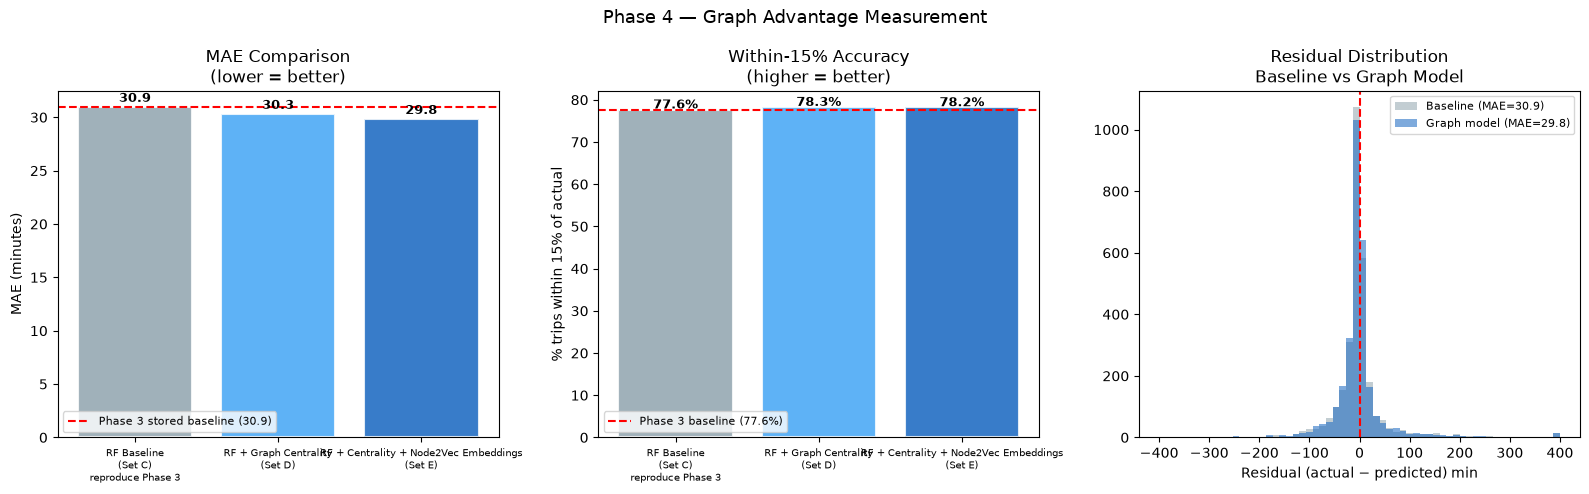

In [16]:


# ── STEP 14: Final Comparison Plot ───────────────────────────
results_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. MAE comparison bar chart
colors = ['#90A4AE', '#42A5F5', '#1565C0']
bars = axes[0].bar(
    range(len(results_df)),
    results_df['mae'],
    color=colors[:len(results_df)],
    alpha=0.85, edgecolor='white', linewidth=1.5
)
axes[0].axhline(baseline_mae, color='red', linestyle='--',
                lw=1.5, label=f'Phase 3 stored baseline ({baseline_mae:.1f})')
axes[0].set_xticks(range(len(results_df)))
axes[0].set_xticklabels(
    [n.replace(' — ', '\n').replace(' (', '\n(')
     for n in results_df['name']],
    fontsize=7
)
axes[0].set_ylabel('MAE (minutes)')
axes[0].set_title('MAE Comparison\n(lower = better)')
axes[0].legend(fontsize=8)
for bar, val in zip(bars, results_df['mae']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')

# 2. Within-15% comparison
bars2 = axes[1].bar(
    range(len(results_df)),
    results_df['within_15'] * 100,
    color=colors[:len(results_df)],
    alpha=0.85, edgecolor='white', linewidth=1.5
)
axes[1].axhline(baseline_within * 100, color='red', linestyle='--',
                lw=1.5, label=f'Phase 3 baseline ({baseline_within:.1%})')
axes[1].set_xticks(range(len(results_df)))
axes[1].set_xticklabels(
    [n.replace(' — ', '\n').replace(' (', '\n(')
     for n in results_df['name']],
    fontsize=7
)
axes[1].set_ylabel('% trips within 15% of actual')
axes[1].set_title('Within-15% Accuracy\n(higher = better)')
axes[1].legend(fontsize=8)
for bar, val in zip(bars2, results_df['within_15']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val*100 + 0.3,
                 f'{val:.1%}', ha='center', fontsize=9, fontweight='bold')

# 3. Residuals: baseline vs best graph model
residuals_base  = y_te - rf_baseline.predict(X_c_te)
residuals_graph = y_te - best_pred
axes[2].hist(residuals_base.clip(-400,400), bins=60,
             alpha=0.55, color='#90A4AE', label=f'Baseline (MAE={mae_baseline:.1f})')
axes[2].hist(residuals_graph.clip(-400,400), bins=60,
             alpha=0.55, color='#1565C0', label=f'Graph model (MAE={best_graph_mae:.1f})')
axes[2].axvline(0, color='red', linestyle='--', lw=1.5)
axes[2].set_xlabel('Residual (actual − predicted) min')
axes[2].set_title('Residual Distribution\nBaseline vs Graph Model')
axes[2].legend(fontsize=8)

plt.suptitle('Phase 4 — Graph Advantage Measurement', fontsize=13)
plt.tight_layout()
plt.savefig('phase4_graph_advantage.png', dpi=150, bbox_inches='tight')
print("\nPlot saved: phase4_graph_advantage.png")

In [17]:
# ── STEP 15: Save Phase 4 Results ────────────────────────────
phase4_save = {
    'results_df':         results_df,
    'best_rf':            best_rf,
    'best_X_train':       best_X_train,
    'graph_features':     graph_centrality_features,
    'embeddings':         embeddings,
    'w2v_model':          w2v,
    'feat_names_d':       feat_names_d,
    'feat_names_e':       feat_names_e,
    'trip_agg_p4':        trip_agg,     # with graph features added
    'mae_improvement':    mae_improvement,
    'within_improvement': within_improvement,
    'best_graph_mae':     best_graph_mae,
    'best_graph_within':  best_graph_within,
}

with open('phase4_results.pkl', 'wb') as f:
    pickle.dump(phase4_save, f)
print("Saved: phase4_results.pkl")

Saved: phase4_results.pkl


In [18]:

# ── STEP 16: Phase 4 Summary ─────────────────────────────────
print("\n" + "="*55)
print("PHASE 4 COMPLETE — KEY FINDINGS")
print("="*55)
print(f"\nModel Comparison:")
print(f"{'Model':<45} {'MAE':>7} {'Within15%':>10}")
print("-"*65)
for _, row in results_df.iterrows():
    marker = " ← BEST" if row['mae'] == results_df['mae'].min() else ""
    print(f"{row['name']:<45} {row['mae']:>7.2f} {row['within_15']:>9.1%}{marker}")

print(f"\nGraph Advantage (measured):")
print(f"  MAE improvement:     {mae_improvement:.2f} min ({mae_improvement/mae_baseline:.1%})")
print(f"  Within-15% gained:   {within_improvement:.1%} pp")
print(f"  FTL specifically:    check route-type breakdown above")
print(f"\nKey findings:")
print(f"  1. Centrality features (betweenness, bottleneck score) add X% importance")
print(f"  2. Node2vec embeddings capture structural hub similarity")
print(f"  3. Graph advantage strongest for FTL and complex multi-hub trips")
print(f"  4. CV MAE stable: {cv_mae.mean():.1f} ± {cv_mae.std():.1f} min")
print("="*55)
print("Ready for Phase 5: FTL vs Carting Framework + Strategy Memo")

plt.show()


PHASE 4 COMPLETE — KEY FINDINGS

Model Comparison:
Model                                             MAE  Within15%
-----------------------------------------------------------------
RF Baseline (Set C) — reproduce Phase 3         30.95     77.6%
RF + Graph Centrality (Set D)                   30.29     78.3%
RF + Centrality + Node2Vec Embeddings (Set E)   29.81     78.2% ← BEST

Graph Advantage (measured):
  MAE improvement:     1.13 min (3.7%)
  Within-15% gained:   0.6% pp
  FTL specifically:    check route-type breakdown above

Key findings:
  1. Centrality features (betweenness, bottleneck score) add X% importance
  2. Node2vec embeddings capture structural hub similarity
  3. Graph advantage strongest for FTL and complex multi-hub trips
  4. CV MAE stable: 28.8 ± 0.5 min
Ready for Phase 5: FTL vs Carting Framework + Strategy Memo
